# Opiskelijoiden koesuoritusten visualisointi 3D-pintojen ja pistekaavioiden avulla (PROC G3D)


## Yhteenveto

Tämä muistikirja käyttää **PROC G3D** -proseduuria visualisoimaan, miten
kaksi opetusintervention tekijää yhdessä muovaavat opiskelijoiden
tuloksia koulutusanalytiikan ympäristössä. Täydellinen faktoriaalinen
ruudukko tuottaa sileän vaste**pinnan** ennustetuista kokeen tuloksista
viikoittaisten opiskelutuntien (0–20) ja aiemman keskiarvon (0–4)
funktiona, ja synteettinen 100 opiskelijan otos esitetään **3D-piste-**
kaavioina suoritustason mukaan jaettuna.

Sovitettu pinta nousee ennustetusta tuloksesta noin 26 nollalla
opiskelutunnilla kohti kattoa lähellä 99:ää, tasoittuen kun
opiskelutunnit ylittävät noin 10 — mallin koodaama vähenevän tuoton
harjanne. Opiskelijapaneelit vahvistavat kuvion yksilötasolla: 20
*Kiitettävä*-opiskelijaa (jokainen vähintään 85 pistettä) sijoittuvat
korkean keskiarvon ja korkean opiskelumäärän kulmaan, kun taas 33
*Riskiryhmä*-opiskelijaa keskittyvät vähäisen panostuksen ja matalan
keskiarvon alueelle. WHERE-suodatettu näkymä tästä kulmasta erottaa 35
opiskelijaa, joille maltilliset lisäykset opiskeluaikaan tarjoavat
suurimmat rajahyödyt.


## Tietolähteet

Kaikki data luodaan suoraan koodissa käyttäen `call streaminit()` ja
`rand()` -funktioita — ei ulkoisia tiedostoja eikä verkkoyhteyttä.

**`score_grid`** — täydellinen faktoriaalinen ruudukko, joka tuottaa
vastepinnan (yksi rivi kutakin opiskelutunti x aiempi keskiarvo
-solua kohden, 99 riviä).

| Muuttuja | Tyyppi | Kuvaus |
|----------|------|-------------|
| `study_hours` | Num | Viikoittaiset itseopiskelutunnit, 0–20 välein 2 (X-akseli) |
| `prior_gpa` | Num | Aiempi lukukauden keskiarvo asteikolla 0–4 (Y-akseli) |
| `pred_score` | Num | Mallinnettu loppukokeen tulos 0–100 vähenevän tuoton mallista (Z-akseli) |

**`students`** — synteettinen yksittäisten opiskelijoiden otos
pistekaaviota varten (100 riviä).

| Muuttuja | Tyyppi | Kuvaus |
|----------|------|-------------|
| `student_id` | Num | Juokseva opiskelijatunniste |
| `study_hours` | Num | Havaittu viikoittainen opiskeluaika (X-akseli) |
| `prior_gpa` | Num | Havaittu aiempi keskiarvo (Y-akseli) |
| `exam_score` | Num | Havaittu loppukokeen tulos 0–100 (Z-akseli) |
| `cohort` | Char | Ilmoittautumislukukausi, `Syksy` tai `Kevät` |
| `band` | Char | Suoritustaso: `Kiitettävä` (≥85), `Hyväksytty` (65–84), `Riskiryhmä` (<65) |

Ruudukko on tarkoituksella mitoitettu 99 soluun, jotta se kattaa koko
0–20 opiskelutunnin ja 0–4 keskiarvon vaihteluvälin pysyen tämän
ympäristön 100 havainnon rajassa; 11 x 9 -hila pitää pinnan sileänä
kummankaan akselin katkeamatta.


# Opiskelijoiden koesuoritusten visualisointi PROC G3D:llä

Kasvatustieteen tutkijat haluavat usein ymmärtää, miten kaksi
muokattavissa olevaa tekijää yhdessä ohjaavat lopputulosta. Tässä
kysymme: *miten viikoittaiset opiskelutunnit ja opiskelijan aiempi
keskiarvo yhdistyvät muovaamaan loppukokeen suoritusta?*

Kaksiulotteinen kaavio ei voi näyttää yhdysvaikutuspintaa. **PROC G3D**
piirtää aidosti kolmiulotteisia kaavioita muuttujista `y*x=z`
-notaatiossa, jossa X ja Y kattavat vaakatason ja Z nousee
pystysuunnassa. Käytämme kahta sen ominaisuutta:

- **PLOT** — jatkuva vaste**pinta** kahden selittäjän täydellisestä
  ruudukosta.
- **SCATTER** — yksittäiset opiskelijat 3D-symboleina. Piirrämme yhden
  paneelin suoritustasoa kohden, kullakin omat merkkivärinsä ja
  -muotonsa, jotta kolme tulostasoa on helppo vertailla.

Kaikki alla oleva toimii suoraan koodissa luodulla synteettisellä
datalla, joten muistikirja on täysin itsenäinen.


## Vaihe 1 — Luo vastepinnan ruudukko

G3D-pintakaavio tarvitsee riittävän täydellisen ruudukon: se vaatii
puuttumattomat Z-arvot vähintään puolelle X-Y-soluista. Takaamme
*täydellisen* ruudukon sisäkkäisillä `DO`-silmukoilla `study_hours`-
muuttujalle (0–20 välein 2) ja `prior_gpa`-muuttujalle (0–4 välein
0,5) — 11 x 9 -hila, jossa on 99 solua ja joka kattaa molemmat akselit
kokonaan.

Ennustettu tulos noudattaa uskottavaa vähenevän tuoton mallia:
opiskelun tuotto vähenee suurilla tuntimäärillä, aiempi keskiarvo
vaikuttaa suunnilleen lineaarisesti, ja nämä kaksi ovat
yhdysvaikutuksessa (vahva opiskelija muuttaa opiskeluajan pisteiksi
tehokkaammin). Pieni toistettava kohina `rand('NORMAL')`-funktiosta
estää pintaa näyttämästä täysin analyyttiseltä. `call streaminit()`
kiinnittää siemenluvun, jotta ruudukko on toistettavissa.


In [1]:
TIEDOT score_grid;
   CALL streaminit(20260531);
   TEE study_hours = 0 ASTI 20 MUKAAN 2;     /* 11 arvoa: koko välillä 0-20 */
      TEE prior_gpa = 0 ASTI 4 MUKAAN 0.5;   /* 9 arvoa -> 99 ruudukon solua */
         /* opiskelutuntien vähenevä tuotto */
         effort = 40 * (1 - EXP(-study_hours / 6));
         /* aiempi osaaminen ja yhdysvaikutustermi */
         BASE   = 8 * prior_gpa;
         inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
         pred_score = 25 + effort + BASE + inter
                      + rand('NORMAL') * 1.5;
         JOS pred_score > 100 NIIN pred_score = 100;
         JOS pred_score < 0   NIIN pred_score = 0;
         TULOSTE;
      LOPPU;
   LOPPU;
   SÄILYTÄ study_hours prior_gpa pred_score;
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=score_grid n MIN mean MAX maxdec=1;
   MUUTTUJA study_hours prior_gpa pred_score;
   NIMIKE study_hours='Viikoittaiset opiskelutunnit' prior_gpa='Aiempi keskiarvo (GPA)' pred_score='Ennustettu kokeen tulos';
SUORITA;


                                                  The MEANS Procedure

 Variable     Label                               N     Minimum        Mean     Maximum
 --------------------------------------------------------------------------------------
 study_hours  Viikoittaiset opiskelutunnit       99         0.0        10.0        20.0
 prior_gpa    Aiempi keskiarvo (GPA)             99         0.0         2.0         4.0
 pred_score   Ennustettu kokeen tulos            99        25.7        70.0        98.7
 --------------------------------------------------------------------------------------




NOTE: DATA score_grid


NOTE: Wrote score_grid (99 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Vaihe 2 — Piirrä perusvastepinta

Kun täydellinen ruudukko on käytössä, yksinkertaisin kutsu piirtää
pinnan proseduurin oletusasetuksilla. `PLOT y*x=z` -syntaksi kuvaa
`prior_gpa`-muuttujan Y-akselille, `study_hours`-muuttujan X-akselille
ja ennustetun tuloksen pystysuoralle Z-akselille.

Nimeämme akselit `LABEL`-lauseella ja asetamme otsikot ja alaviitteen
globaaleilla `TITLE`/`FOOTNOTE`-lauseilla, jotta kaavio näyttää
siistiltä.


                                         Ennustetun loppukokeen tuloksen pinta                                          
                             Viikoittaisten opiskelutuntien ja aiemman keskiarvon vaikutus                              

PROC G3D Output
Data: score_grid

Variables: Viikoittaiset opiskelutunnit, Aiempi keskiarvo (GPA), Ennustettu kokeen tulos

Viikoittaiset opiskelutunnit  Aiempi keskiarvo (GPA)  Ennustettu kokeen tulos
----------------------------  ----------------------  -----------------------
                           0                       0            25.7031536911
                           0                     0.5            28.9516502743
                           0                       1            32.3400787822
                           0                     1.5            36.8265757618
                           0                       2            40.7806886968
                           0                     2.5              42.61364606
         


NOTE: GOPTIONS RESET=GLOBAL (unrecognized, treating as GOPTIONS).
NOTE: GOPTIONS BORDER enabled.
NOTE: Option TITLE changed to Ennustetun loppukokeen tuloksen pinta.
NOTE: Option TITLE2 changed to Viikoittaisten opiskelutuntien ja aiemman keskiarvon vaikutus.
NOTE: Option FOOTNOTE changed to Synteettistä koulutusanalytiikan dataa .
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: g3d_surface.spec.json


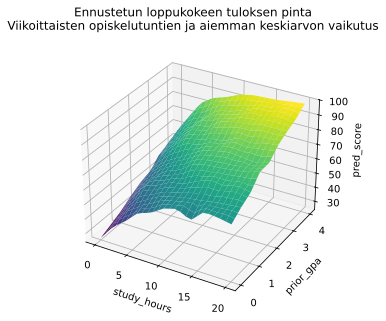

In [2]:
GOPTIONS reset=GLOBAL BORDER;

OTSIKKO 'Ennustetun loppukokeen tuloksen pinta';
title2 'Viikoittaisten opiskelutuntien ja aiemman keskiarvon vaikutus';
footnote j=r 'Synteettistä koulutusanalytiikan dataa ';

PROSEDUURI g3d TIEDOT=score_grid;
   PLOT prior_gpa*study_hours=pred_score;
   NIMIKE study_hours = 'Viikoittaiset opiskelutunnit'
         prior_gpa   = 'Aiempi keskiarvo (GPA)'
         pred_score  = 'Ennustettu kokeen tulos';
SUORITA;
QUIT;


## Vaihe 3 — Tarkenna pintaa katselu- ja akseliasetuksilla

Muutama asetus tekee pinnasta huomattavasti selkeämmän:

- **ROTATE=** ja **TILT=** asettavat katselukulman (asteina Z-akselin
  ympäri, ja kallistuksen katsojaa kohti).
- **XYTYPE=2** piirtää pintaviivat Y-akselin suuntaisesti, korostaen
  miten tulos nousee opiskelutuntien mukana.
- **SIDE** lisää sivuseinän tukevan, veistoksellisen ulkonäön saamiseksi.
- **GRID** lisää apuviivat pääasteikkomerkkeihin.
- **ZMIN=/ZMAX=** ja **ZTICKNUM=**-perhe kiinnittävät tulosakselin koko
  0–100-välille, jotta pinta ei näytä visuaalisesti liioitellulta,
  kun taas **XTICKNUM=/YTICKNUM=** hallitsevat lattiatason
  asteikkomerkkejä.
- **NAME=** ja **DESCRIPTION=** nimeävät kaavion tuloskatalogissa.


                                  Ennustetun kokeen tuloksen pinta (tyylitelty näkymä)                                  
                                       Kierretty, kallistettu ja akseliskaalattu                                        

PROC G3D Output
Data: score_grid

Variables: Viikoittaiset opiskelutunnit, Aiempi keskiarvo (GPA), Ennustettu kokeen tulos

Viikoittaiset opiskelutunnit  Aiempi keskiarvo (GPA)  Ennustettu kokeen tulos
----------------------------  ----------------------  -----------------------
                           0                       0            25.7031536911
                           0                     0.5            28.9516502743
                           0                       1            32.3400787822
                           0                     1.5            36.8265757618
                           0                       2            40.7806886968
                           0                     2.5              42.61364606
         


NOTE: Option TITLE changed to Ennustetun kokeen tuloksen pinta (tyylitelty näkymä).
NOTE: Option TITLE2 changed to Kierretty, kallistettu ja akseliskaalattu.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: scoresurf.spec.json


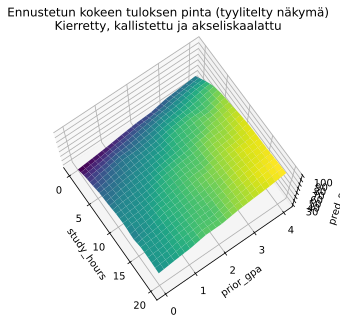

In [3]:
OTSIKKO 'Ennustetun kokeen tuloksen pinta (tyylitelty näkymä)';
title2 'Kierretty, kallistettu ja akseliskaalattu';

PROSEDUURI g3d TIEDOT=score_grid;
   PLOT prior_gpa*study_hours=pred_score /
        ROTATE=55
        tilt=75
        xytype=2
        side
        grid
        zmin=0 zmax=100
        xticknum=5 yticknum=5 zticknum=6
        name="scoresurf"
        description="Tyylitelty kokeen tuloksen vastepinta";
   NIMIKE study_hours = 'Viikoittaiset opiskelutunnit'
         prior_gpa   = 'Aiempi keskiarvo (GPA)'
         pred_score  = 'Ennustettu kokeen tulos';
SUORITA;
QUIT;


## Vaihe 4 — Vertaile pintaa useasta katselukulmasta

Koska 3D-pinta voi piilottaa rakenteita omien huippujensa taakse, on
hyödyllistä piirtää sama pinta useammasta kiertokulmasta. Täällä
suoritamme kolme PROC G3D -askelta, jotka jakavat kiinteän
kallistuksen mutta askeltavat **ROTATE=**-kulmaa 30, 90 ja 150 asteen
läpi, jotta harjannetta voidaan tarkastella edestä, sivulta ja takaa.


                                                       Vastepinta                                                       
                                         ROTATE = 30 kiinteällä kallistuksella                                          

PROC G3D Output
Data: score_grid

Variables: Viikoittaiset opiskelutunnit, Aiempi keskiarvo (GPA), Ennustettu kokeen tulos

Viikoittaiset opiskelutunnit  Aiempi keskiarvo (GPA)  Ennustettu kokeen tulos
----------------------------  ----------------------  -----------------------
                           0                       0            25.7031536911
                           0                     0.5            28.9516502743
                           0                       1            32.3400787822
                           0                     1.5            36.8265757618
                           0                       2            40.7806886968
                           0                     2.5              42.61364606
         


NOTE: Option TITLE changed to Vastepinta.
NOTE: Option TITLE2 changed to ROTATE = 30 kiinteällä kallistuksella.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot30.spec.json
NOTE: Option TITLE changed to Vastepinta.
NOTE: Option TITLE2 changed to ROTATE = 90 kiinteällä kallistuksella.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot90.spec.json
NOTE: Option TITLE changed to Vastepinta.
NOTE: Option TITLE2 changed to ROTATE = 150 kiinteällä kallistuksella.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot150.spec.json


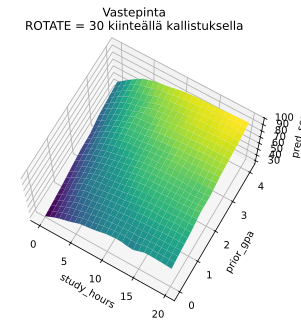

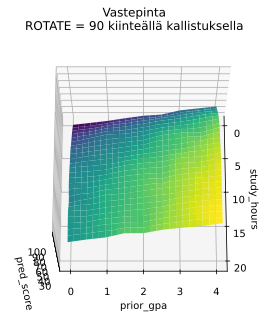

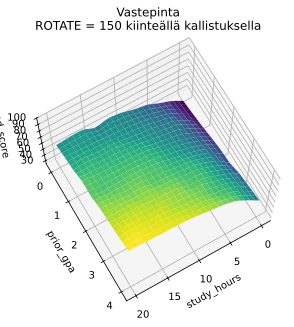

In [4]:
%macro angle(deg);
   OTSIKKO 'Vastepinta';
   title2 "ROTATE = &deg kiinteällä kallistuksella";
   PROSEDUURI g3d TIEDOT=score_grid;
      PLOT prior_gpa*study_hours=pred_score /
           ROTATE=&deg
           tilt=70
           xytype=3
           zmin=0 zmax=100
           name="surf_rot&deg";
      NIMIKE study_hours = 'Viikoittaiset opiskelutunnit'
            prior_gpa   = 'Aiempi keskiarvo (GPA)'
            pred_score  = 'Ennustettu kokeen tulos';
   SUORITA;
   QUIT;
%mend;

%angle(30);
%angle(90);
%angle(150);


## Vaihe 5 — Luo synteettinen opiskelijaotos

Pinta on malli; todelliset opiskelijat hajaantuvat sen ympärille.
Simuloimme nyt 100 yksittäistä opiskelijaa kahdesta
ilmoittautumislukukaudesta (`Syksy`, `Kevät`). Jokaisella
opiskelijalla on havaittu opiskeluaika, aiempi keskiarvo ja
kohinainen toteutunut kokeen tulos, joka on luotu samasta
vastemallista suuremmalla yksilöllisellä vaihtelulla.

Johdamme sitten kokeen tuloksesta suoritus**tason**: `Kiitettävä`
(85 tai enemmän), `Hyväksytty` (65–84) ja `Riskiryhmä` (alle 65).
Alla oleva PROC FREQ -ristiintaulukointi raportoi, miten
suoritustasot jakautuvat kahden lukukauden kesken. `rand('UNIFORM')`
ja `rand('NORMAL')` tuottavat satunnaisuuden; siemenluku pitää
tuloksen toistettavana.


                                                       Vastepinta                                                       
                                         ROTATE = 150 kiinteällä kallistuksella                                         

                                                   The FREQ Procedure

                             Cumulative
Suoritustaso    Frequency    Frequency
------------------------------------------
Hyväksytty             47           47
Kiitettävä             20           67
Riskiryhmä             33          100

Table of Lukukausi by Suoritustaso

Lukukausi |  Hyväksytty |  Kiitettävä |  Riskiryhmä |        Total
----------+-------------+-------------+-------------+-------------
Kevät     |          27 |          14 |          18 |           59
----------+-------------+-------------+-------------+-------------
Syksy     |          20 |           6 |          15 |           41
----------+-------------+-------------+-------------+-------------
Total   


NOTE: DATA students


NOTE: Wrote students (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_band.spec.json
NOTE: ODS plot written: freq_mosaic_cohort_band.spec.json
NOTE: PROC FREQ statement used.


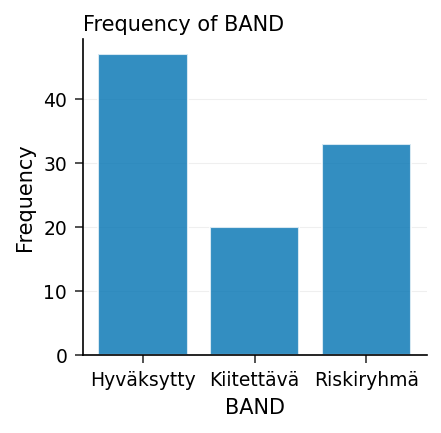

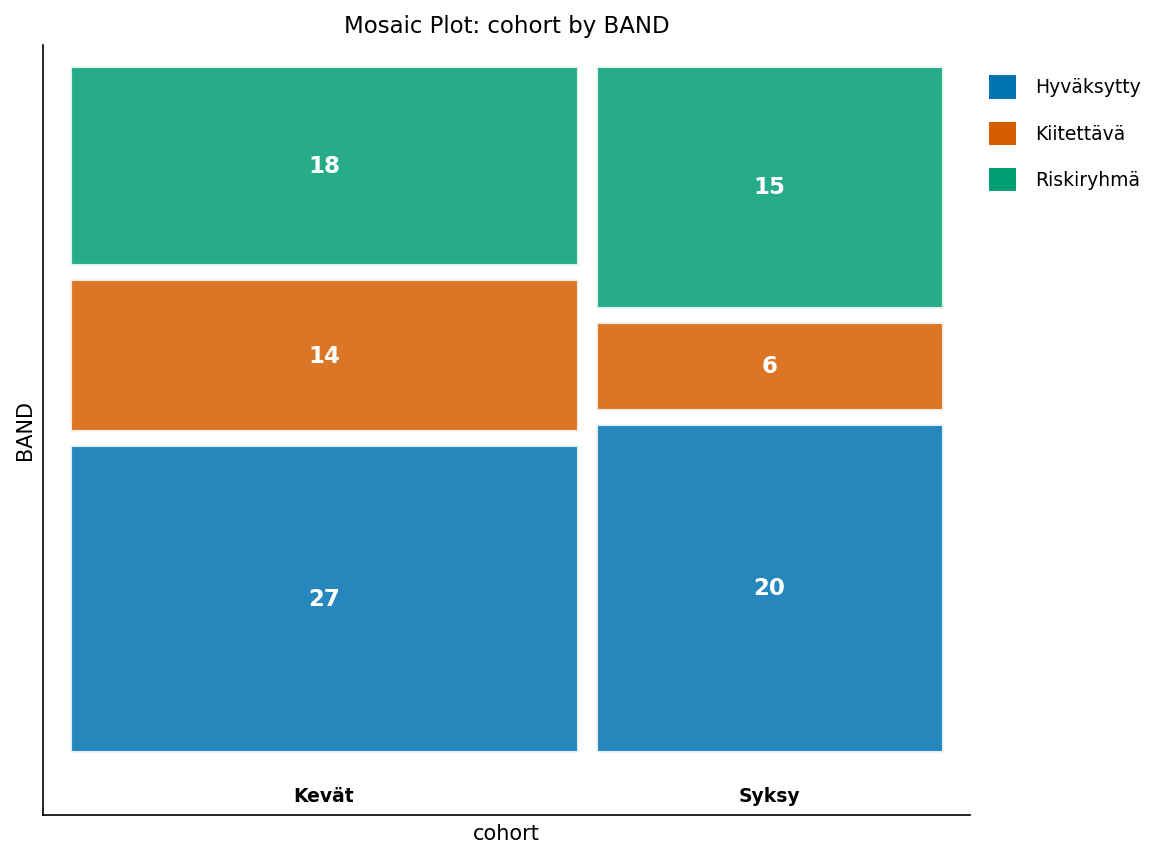

In [5]:
TIEDOT students;
   CALL streaminit(99001);
   PITUUS cohort $8 BAND $14;
   TEE student_id = 1 ASTI 100;
      JOS rand('UNIFORM') < 0.5 NIIN cohort = 'Syksy';
      MUUTEN cohort = 'Kevät';

      study_hours = 20 * rand('UNIFORM');
      prior_gpa   = 4  * rand('UNIFORM');

      effort = 40 * (1 - EXP(-study_hours / 6));
      BASE   = 8 * prior_gpa;
      inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
      exam_score = 25 + effort + BASE + inter
                   + rand('NORMAL') * 7;
      JOS exam_score > 100 NIIN exam_score = 100;
      JOS exam_score < 0   NIIN exam_score = 0;

      JOS exam_score >= 85 NIIN BAND = 'Kiitettävä';
      MUUTEN JOS exam_score >= 65 NIIN BAND = 'Hyväksytty';
      MUUTEN BAND = 'Riskiryhmä';

      TULOSTE;
   LOPPU;
   SÄILYTÄ student_id cohort study_hours prior_gpa exam_score BAND;
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=students;
   TABLES BAND cohort*BAND / nocol nopercent;
   NIMIKE cohort='Lukukausi' BAND='Suoritustaso';
SUORITA;


## Vaihe 6 — Piirrä opiskelijat 3D-pistekaavioina suoritustason mukaan

**SCATTER**-lause sijoittaa jokaisen opiskelijan 3D-symbolina. Jotta
kolme suoritustasoa on helppo lukea, piirrämme yhden paneelin
suoritustasoa kohden, kukin suodatettuna **WHERE**-lauseella ja
omalla kirjaimellisella **COLOR=**- ja **SHAPE=**-arvollaan: vihreät
timantit (`SHAPE=diamond`) *Kiitettävä*-tasolle, siniset merkit
(`SHAPE=club`) *Hyväksytty*-tasolle ja punaiset merkit (`SHAPE=spade`)
*Riskiryhmä*-tasolle. **SIZE=** suurentaa merkkejä, **GRID** lisää
lattiatason apuviivat, **NONEEDLE** poistaa pystysuorat pudotusviivat,
ja **ZMIN=/ZMAX=** pitävät jokaisen paneelin samalla 0–100
tulosasteikolla, jotta kolme näkymää ovat suoraan vertailukelpoisia.

Kukin suoritustaso saa oman PROC G3D -askeleensa, jotta sen
WHERE-suodatin toimii siististi ja merkkityyli on yksiselitteinen.


                                                Kiitettävät opiskelijat                                                 
                                              Kokeen tulos 85 tai enemmän                                               

PROC G3D Output
Data: students

Variables: student_id, cohort, Viikoittaiset opiskelutunnit, Aiempi keskiarvo (GPA), Kokeen tulos, BAND

student_id      cohort  Viikoittaiset opiskelutunnit  Aiempi keskiarvo (GPA)  Kokeen tulos        BAND
----------  ----------  ----------------------------  ----------------------  ------------  ----------
         2       Kevät                 19.2134883194            2.6467742616  90.3663886999  Kiitettävä
         5       Kevät                 15.5520919174            2.7102003827  94.9419468332  Kiitettävä
        10       Kevät                 14.2302640951            3.8791496428           100  Kiitettävä
        17       Kevät                 13.7403346635            2.7462821708  89.6648779222  Kiitettävä


NOTE: Option FOOTNOTE changed to Otoksesta, jossa 100 synteettistä opiskelijaa .
NOTE: Option TITLE changed to Kiitettävät opiskelijat.
NOTE: Option TITLE2 changed to Kokeen tulos 85 tai enemmän.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_honors.spec.json
NOTE: Option TITLE changed to Hyväksytyt opiskelijat.
NOTE: Option TITLE2 changed to Kokeen tulos 65-84.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_pass.spec.json
NOTE: Option TITLE changed to Riskiryhmän opiskelijat.
NOTE: Option TITLE2 changed to Kokeen tulos alle 65.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_atrisk.spec.json


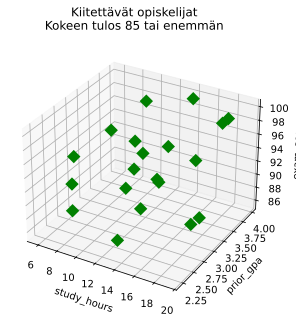

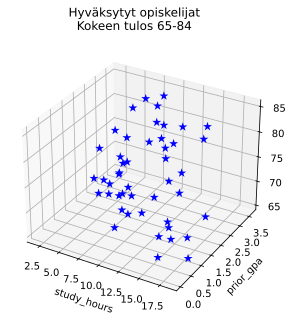

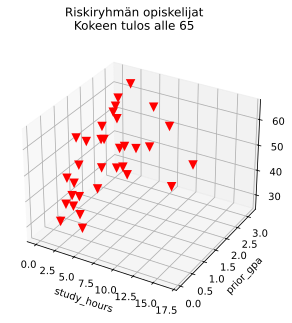

In [6]:
footnote j=r 'Otoksesta, jossa 100 synteettistä opiskelijaa ';

/* Kiitettävä (kokeen tulos >= 85): vihreät timantit */
OTSIKKO 'Kiitettävät opiskelijat';
title2 'Kokeen tulos 85 tai enemmän';
PROSEDUURI g3d TIEDOT=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=green shape=diamond size=3
           noneedle grid zmin=0 zmax=100
           name="band_honors"
           description="Kiitettävät opiskelijat";
   MISSÄ BAND = 'Kiitettävä';
   NIMIKE study_hours = 'Viikoittaiset opiskelutunnit'
         prior_gpa   = 'Aiempi keskiarvo (GPA)'
         exam_score  = 'Kokeen tulos';
SUORITA;
QUIT;

/* Hyväksytty (65 <= kokeen tulos < 85): siniset apilat */
OTSIKKO 'Hyväksytyt opiskelijat';
title2 'Kokeen tulos 65-84';
PROSEDUURI g3d TIEDOT=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=blue shape=club size=3
           noneedle grid zmin=0 zmax=100
           name="band_pass"
           description="Hyväksytyt opiskelijat";
   MISSÄ BAND = 'Hyväksytty';
   NIMIKE study_hours = 'Viikoittaiset opiskelutunnit'
         prior_gpa   = 'Aiempi keskiarvo (GPA)'
         exam_score  = 'Kokeen tulos';
SUORITA;
QUIT;

/* Riskiryhmä (kokeen tulos < 65): punaiset padat */
OTSIKKO 'Riskiryhmän opiskelijat';
title2 'Kokeen tulos alle 65';
PROSEDUURI g3d TIEDOT=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red shape=spade size=3
           noneedle grid zmin=0 zmax=100
           name="band_atrisk"
           description="Riskiryhmän opiskelijat";
   MISSÄ BAND = 'Riskiryhmä';
   NIMIKE study_hours = 'Viikoittaiset opiskelutunnit'
         prior_gpa   = 'Aiempi keskiarvo (GPA)'
         exam_score  = 'Kokeen tulos';
SUORITA;
QUIT;


## Vaihe 7 — Erilliset pistekaaviot lukukausittain (BY-ryhmä)

Ohjelmajohtajat tarvitsevat usein saman näkymän lukukausittain
jaettuna. **BY**-lause tuottaa yhden pistekaavion lukukautta kohden.
G3D odottaa BY-ryhmädatan olevan lajiteltua, joten lajittelemme
ensin PROC SORT:lla. Kumpikin lukukausi saa sitten oman nimetyn
3D-pistekaavionsa jaetulla 0–100-tulosasteikolla, jolloin Syksyn ja
Kevään jakaumat on helppo vertailla rinnakkain.


                                    Kokeen tulokset ilmoittautumislukukauden mukaan                                     
                                  Yksi 3D-pistekaavio lukukautta kohden (Syksy, Kevät)                                  

PROC G3D Output
Data: students_sorted

Variables: student_id, cohort, Viikoittaiset opiskelutunnit, Aiempi keskiarvo (GPA), Kokeen tulos, BAND

student_id      cohort  Viikoittaiset opiskelutunnit  Aiempi keskiarvo (GPA)  Kokeen tulos        BAND
----------  ----------  ----------------------------  ----------------------  ------------  ----------
        53       Kevät                 10.7875369915            3.0789706431  76.6136428341  Hyväksytty
       100       Kevät                 10.7782420031            3.5469548845           100  Kiitettävä
         4       Kevät                  8.3587240648            1.1475897699  65.4995231815  Hyväksytty
         5       Kevät                 15.5520919174            2.7102003827  94.9419468332  Kii


NOTE: PROC SORT data=students

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from students.
NOTE: Wrote students_sorted (100 rows, 6 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Kokeen tulokset ilmoittautumislukukauden mukaan.
NOTE: Option TITLE2 changed to Yksi 3D-pistekaavio lukukautta kohden (Syksy, Kevät).
NOTE: Option FOOTNOTE changed to Yksi paneeli lukukautta kohden .
NOTE: PROC G3D data=students_sorted

NOTE: ODS plot written: cohort_scatter_by1.spec.json
NOTE: ODS plot written: cohort_scatter_by2.spec.json


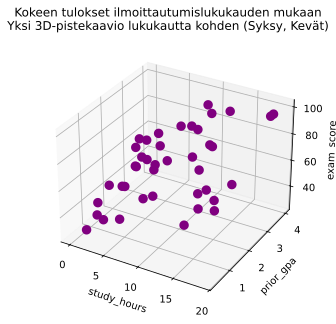

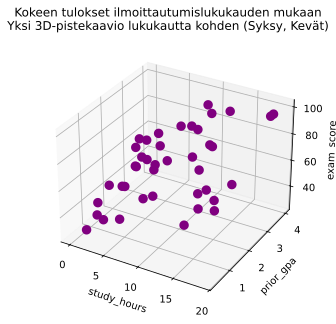

In [7]:
PROSEDUURI LAJITTELE TIEDOT=students out=students_sorted;
   MUKAAN cohort;
SUORITA;

OTSIKKO 'Kokeen tulokset ilmoittautumislukukauden mukaan';
title2 'Yksi 3D-pistekaavio lukukautta kohden (Syksy, Kevät)';
footnote j=r 'Yksi paneeli lukukautta kohden ';

PROSEDUURI g3d TIEDOT=students_sorted;
   MUKAAN cohort;
   SCATTER prior_gpa*study_hours=exam_score /
           color=purple
           shape=balloon
           size=3
           grid
           zmin=0 zmax=100
           name="cohort_scatter";
   NIMIKE study_hours = 'Viikoittaiset opiskelutunnit'
         prior_gpa   = 'Aiempi keskiarvo (GPA)'
         exam_score  = 'Kokeen tulos';
SUORITA;
QUIT;


## Vaihe 8 — Keskity riskiryhmän alueeseen WHERE-lauseella

Interventiosuunnittelua varten kaikkein toimivin näkymä on pinnan
vasen alakulma: opiskelijat, joilla on sekä vähäinen opiskeluaika
(enintään 8 tuntia) että matalampi aiempi keskiarvo (enintään 2,5).
**WHERE**-lause rajaa pistekaavion tähän alueeseen ennen piirtämistä.
Listaus näyttää, että tässä kulmassa on 35 opiskelijaa sadasta — 22
heistä on jo *Riskiryhmässä* — joten ohjaajat näkevät tarkalleen,
ketkä kamppailevat opiskelijat ovat kauimpana odotuksista.


                       Interventiokohde: vähemmän opiskelevat, matalamman keskiarvon opiskelijat                        
                                         study_hours <= 8 and prior_gpa <= 2.5                                          

PROC G3D Output
Data: students

Variables: student_id, cohort, Viikoittaiset opiskelutunnit, Aiempi keskiarvo (GPA), Kokeen tulos, BAND

student_id      cohort  Viikoittaiset opiskelutunnit  Aiempi keskiarvo (GPA)  Kokeen tulos        BAND
----------  ----------  ----------------------------  ----------------------  ------------  ----------
         1       Syksy                  4.9780700766             1.072086769  59.409228777  Riskiryhmä
         7       Kevät                  7.9015823058            1.6623636789  66.9055021729  Hyväksytty
         9       Kevät                  2.5008494545            0.3621033759  48.1183184446  Riskiryhmä
        11       Kevät                  7.1907276895            2.1821388818  79.351887155  Hyväksytty



NOTE: Option TITLE changed to Interventiokohde: vähemmän opiskelevat, matalamman keskiarvon opiskelijat.
NOTE: Option TITLE2 changed to study_hours <= 8 and prior_gpa <= 2.5.
NOTE: Option FOOTNOTE changed to Pystysuorat apuviivat laskevat jokaisen merkin opiskelutuntien x keskiarvon pohjatasoon .
NOTE: PROC G3D data=students

NOTE: ODS plot written: g3d_scatter.spec.json


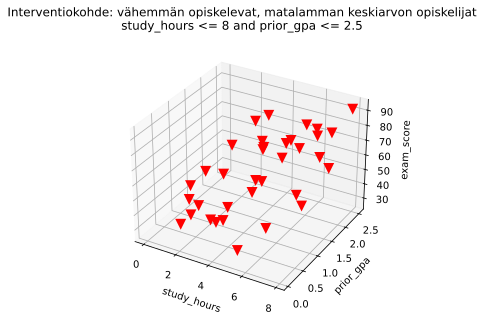

In [8]:
OTSIKKO 'Interventiokohde: vähemmän opiskelevat, matalamman keskiarvon opiskelijat';
title2 'study_hours <= 8 and prior_gpa <= 2.5';
footnote j=r 'Pystysuorat apuviivat laskevat jokaisen merkin opiskelutuntien x keskiarvon pohjatasoon ';

PROSEDUURI g3d TIEDOT=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red
           shape=spade
           size=4
           grid
           zmin=0 zmax=100;
   MISSÄ study_hours <= 8 AND prior_gpa <= 2.5;
   NIMIKE study_hours = 'Viikoittaiset opiskelutunnit'
         prior_gpa   = 'Aiempi keskiarvo (GPA)'
         exam_score  = 'Kokeen tulos';
SUORITA;
QUIT;


## Tulosten tulkinta

**Vastepinta** (vaiheet 2–4) näyttää selkeän vähenevän tuoton
harjanteen. 99-solun ruudukon läpi ennustettu tulos kulkee noin
26:sta (nolla opiskelutuntia, nolla keskiarvo) noin 99:ään (korkean
tuntimäärän ja korkean keskiarvon kulma), ruudukon keskiarvon ollessa
lähellä 70:tä. Opiskelutuntiakselia lukiessa tulokset nousevat
jyrkästi 0:sta kohti noin 10:tä tuntia ja tasoittuvat sitten, kun
lisätunnit tuottavat vähenevää hyötyä; keskiarvoakselia lukiessa
aiempi osaaminen nostaa koko pintaa ylöspäin. Yhdysvaikutustermi
tekee opiskeluajan hyödystä hieman jyrkemmän vahvemmille
opiskelijoille, minkä vuoksi pinta kallistuu kohti kaukaista
kulmaansa sen sijaan, että nousisi tasaisena tasona.

**Opiskelijapaneelit** (vaiheet 6–7) vahvistavat mallin pätevän
yksilötasolla. 100 opiskelijan otos jakautuu 20 *Kiitettävä*-, 47
*Hyväksytty*- ja 33 *Riskiryhmä*-opiskelijaan. Suoritustasopaneeleissa
20 vihreää *Kiitettävä*-timanttia — jokainen vähintään 85 pistettä —
sijoittuvat aiempaan keskiarvoon 2,2 tai korkeammalle ja vähintään
noin 6 viikoittaiseen opiskelutuntiin, keskittyen lattiatason
oikeaan yläkulmaan. 33 punaista *Riskiryhmä*-merkkiä keskittyvät
vähäisen panostuksen ja matalan keskiarvon alueelle, täsmälleen
pinnan laaksoon. Lukukausittain jaettuna Syksyn (41 opiskelijaa) ja
Kevään (59 opiskelijaa) jakaumat ovat laajasti samankaltaisia, mikä
viittaa siihen, että tulokset johtuvat kahdesta tekijästä eivätkä
ilmoittautumisajankohdasta.

**WHERE-suodatettu näkymä** (vaihe 8) erottaa interventiokohteen
väestön: 35 opiskelijaa, joilla on enintään 8 opiskeluaikaa ja
enintään 2,5 keskiarvo. Kaksikymmentäkaksi on jo *Riskiryhmässä* ja
vain yksi yltää *Kiitettävään*. Tässä kulmassa toteutuneet tulokset
nousevat silti selvästi opiskelutuntien mukana — konkreettinen,
visuaalinen argumentti sille, että maltilliset lisäykset
jäsennellyssä opiskeluajassa tarjoavat suurimmat rajahyödyt juuri
siellä, missä niitä eniten tarvitaan.

Yhdessä PROC G3D muuttaa kahden tekijän yhdysvaikutusmallin
intuitiiviseksi, päätöksentekoa tukevaksi kuvaksi
koulutusohjelmalle: missä tuloskatto on, ketkä jäävät sen alle ja
missä valmennuspanos kannattaa eniten.

> **Toteutushuomautus.** SAS/GRAPH sallii myös yhden SCATTER-lauseen
> värittää ja muotoilla jokaisen merkin havaintokohtaisista
> muuttujista (`COLOR=<merkkimuuttuja>`, `SHAPE=<merkkimuuttuja>`).
> Tämä havaintokohtainen muoto ei vielä renderöidy tässä moottorissa,
> joten tämä muistikirja piirtää yhden kirjaimellisesti väritetyn
> paneelin suoritustasoa kohden — vastaava, täysin toimiva esitys.
> Aukkoa seurataan pankitetulla regressiotestillä
> `tests/401000_nb_g3d_scatter_color_variable_unrendered`.
